# Plotting

One of the main usecases of `SegTraQ` is to compare different segmentation methods. To facilitate this task, you can make use of the plotting module (`pl`).
In order to use it, you need to prepare your data in the form of a dictionary that maps the method name to the corresponding `SegTraQ` object.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

## Data Preparation

First, we need to get the data into the right format. This closely follows the [Xenium Focus](10x_xenium_focus.ipynb).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import anndata as ad
import scanpy as sc
import spatialdata as sd

import segtraq

warnings.filterwarnings(action="ignore")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you wa

In [2]:
# === READING SPATIALDATA OBJECTS ===
sdata_xenium_ws = sd.read_zarr("../../data/xenium_5K_data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/xenium_5K_data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/xenium_5K_data/proseg2.zarr")
sdata_segger_ws = sd.read_zarr("../../data/xenium_5K_data/segger.zarr")

# === CROPPING ===
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h


def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)
sdata_segger = crop(sdata_segger_ws)

# === CREATING SEGTRAQ OBJECTS ===
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_segger = segtraq.SegTraQ(
    sdata_segger, images_key="image", tables_centroid_x_key="cell_centroid_x", tables_centroid_y_key="cell_centroid_y"
)

# === PUTTING EVERYTHING INTO A DICTIONARY ===
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg, "segger": st_segger}

# === REMOVING CONTROL PROBES ===
for method, st in st_dict.items():
    qv = 30 if method == "segger" else 20
    st.filter_control_and_low_quality_transcripts(min_qv=qv)

no parent found for <ome_zarr.reader.Label object at 0x7f84f5c04d70>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5c1e0d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5d25f90>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5c082b0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5e7f950>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5c267b0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5d7a580>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5d79e10>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5c10350>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5c13a50>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5bc96d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f84f5bcbf20>: None


## Run desired metrics
Now, we can run all of the metrics we want on this dataset. For now, we simply run a label transfer and run some `scanpy` functions to compute the UMAP coordinates.

In [3]:
# running computations for UMAP etc.
for _, st in st_dict.items():
    # extracting the anndata object from the spatialdata object and performing appropriate normalization
    adata = st.sdata.tables["table"]
    adata.layers["raw"] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")

# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

# Plotting

Now, we can use the `pl` module to create some plots. All we need to do is pass our dictionary of `SegTraQ` objects.

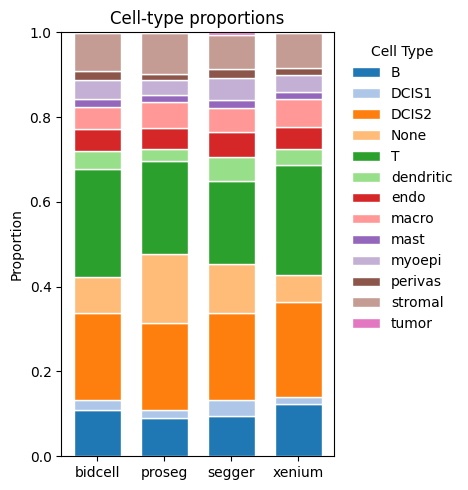

In [4]:
_ = segtraq.pl.celltype_proportions(st_dict, celltype_col="transferred_cell_type")

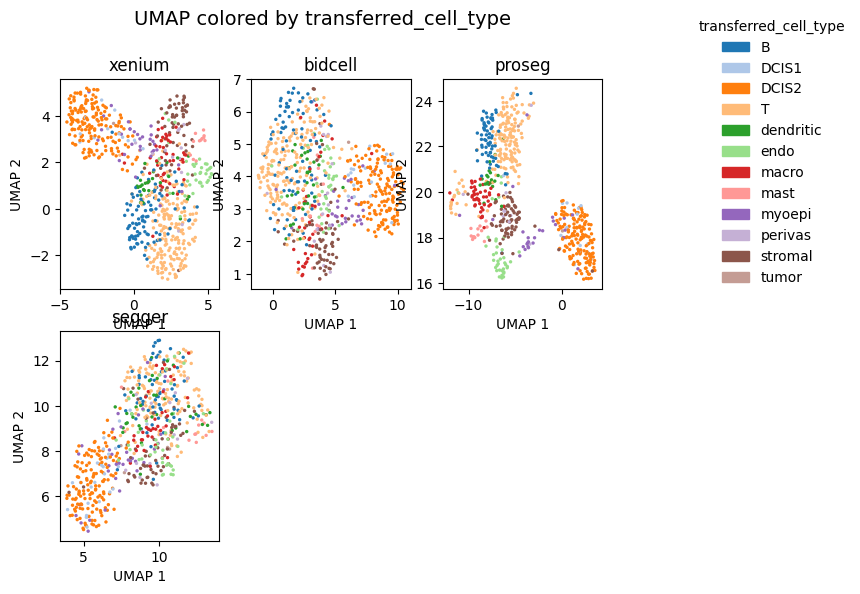

In [5]:
_ = segtraq.pl.umap(st_dict, color="transferred_cell_type", legend=True, figsize=(7, 6))

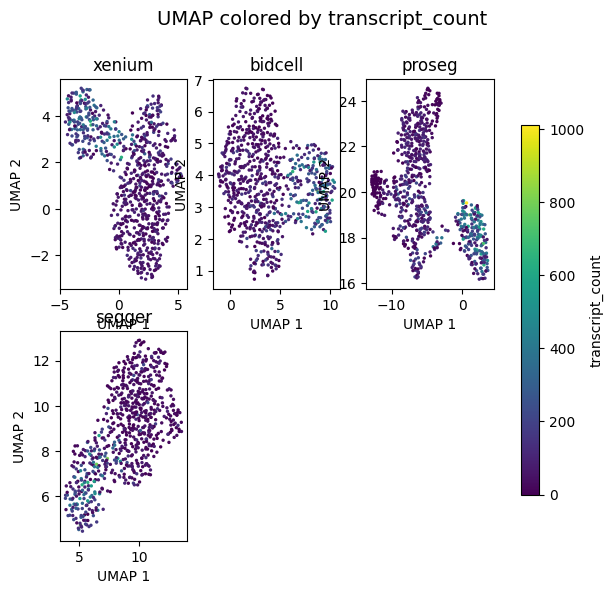

In [6]:
_ = segtraq.pl.umap(st_dict, color="transcript_count", legend=True, figsize=(7, 6))

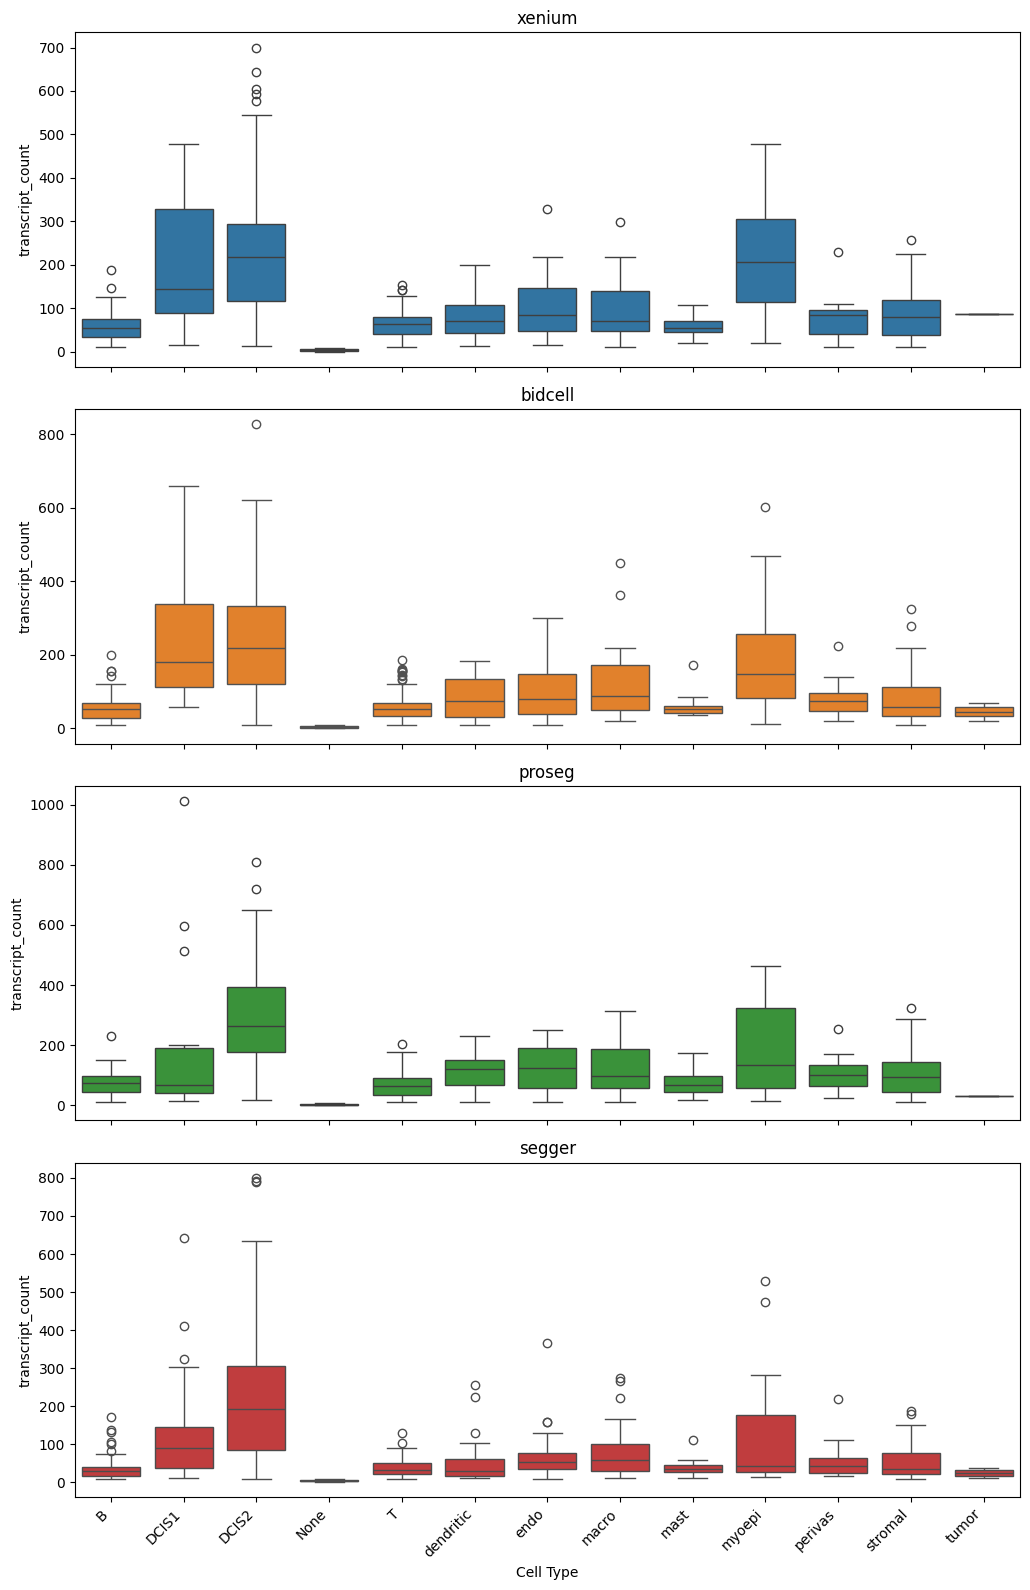

In [7]:
_ = segtraq.pl.boxplot(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

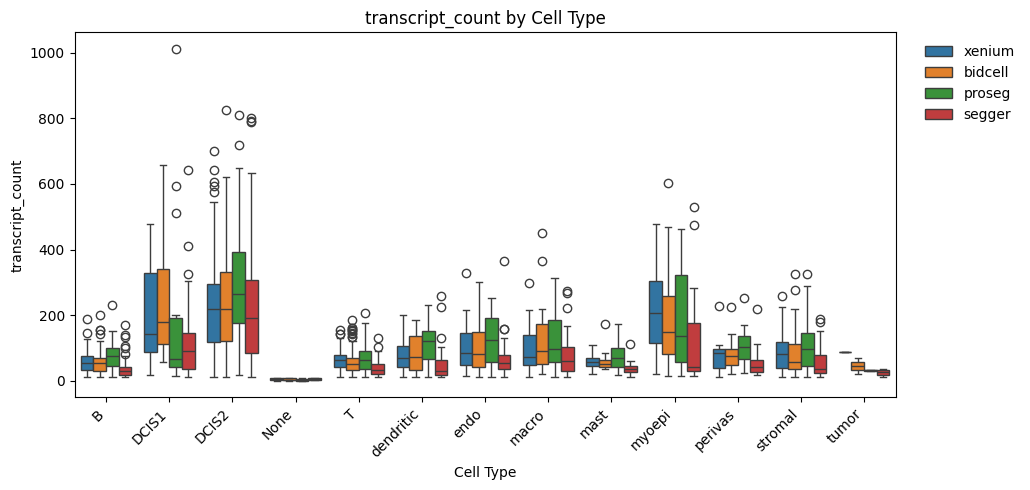

In [8]:
_ = segtraq.pl.boxplot_combined(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

## Session Info

In [9]:
print(sd.__version__)  # spatialdata

0.7.2
